In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

save_fig = True
FIGURES = "../figures"

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
from pypalettes import load_cmap

# Load the colormap

cmap_name = "ralts"
cmap = load_cmap(cmap_name)

plt.set_cmap(cmap_name)

# seaborn
sns.set_palette(cmap_name)

<Figure size 640x480 with 0 Axes>

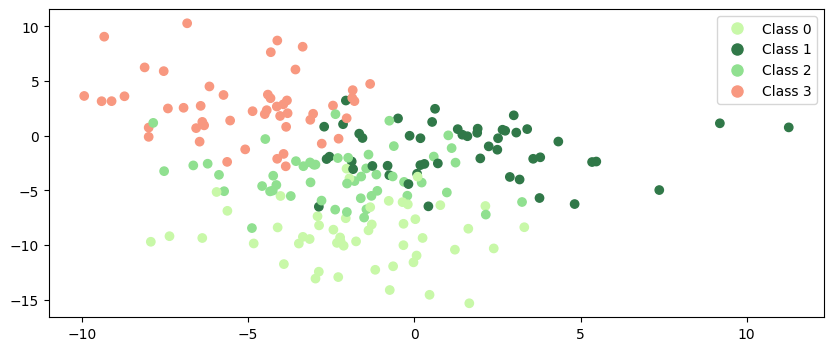

In [3]:
import numpy as np
from sklearn.datasets import make_blobs

generator = np.random.RandomState(2)

size = (200,)
X, y = make_blobs(centers=4, cluster_std=2.5, n_samples=size[0], random_state=generator)

X_0 = X[y == 0]
X_1 = X[y == 1]
X_2 = X[y == 2]

# one-hot encoding for y
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
y_0 = np.full(size[0], 0)
y_1 = np.full(size[0], 1)
y_2 = np.full(size[0], 2)

y_one_hot = encoder.fit_transform(y.reshape(-1, 1))

Z = y_one_hot.copy()
Z /= Z.mean(axis=0, keepdims=True)

Z_0 = Z[y == 0]
Z_1 = Z[y == 1]
Z_2 = Z[y == 2]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.scatter(X[:, 0], X[:, 1], c=y)

# add legend
handles = [
    mpl.lines.Line2D([], [], marker='o', color='w', markerfacecolor=cmap(0), markersize=10, label='Class 0'),
    mpl.lines.Line2D([], [], marker='o', color='w', markerfacecolor=cmap(3), markersize=10, label='Class 1'),
    mpl.lines.Line2D([], [], marker='o', color='w', markerfacecolor=cmap(7), markersize=10, label='Class 2'),
    mpl.lines.Line2D([], [], marker='o', color='w', markerfacecolor=cmap(10), markersize=10, label='Class 3')
]
ax.legend(handles=handles, loc='upper right')

# save image pdf
if save_fig:
    plt.savefig("dummy_multi_data.pdf")

plt.show()

In [4]:
from archetypes import AA
from archetypes import FairAA
from src.metrics import mmd_rbf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score
from tqdm import tqdm
import pandas as pd

metrics = None

aa_params = {
    "n_archetypes": 3,
    "init": "furthest_sum",
    "max_iter": 500,
    "n_init": 5,
    "tol": 1e-12,
    "method": "pgd",
}

best_model = None
best_fair_model = None

for i in tqdm(range(10)):
    
    # AA
    model = AA(
        **aa_params,
        random_state=i,
    )

    _ = model.fit(X)

    S_aa = model.transform(X)
    S_0_aa = model.transform(X_0)
    S_1_aa = model.transform(X_1)
    S_2_aa = model.transform(X_2)

    X_aa = S_aa @ model.archetypes_

    # FairAA
    fair_model = FairAA(
        **aa_params,
        fairness_const=1,
        random_state=i,
    )

    _ = fair_model.fit(X, Z=Z)

    S_fair = fair_model.transform(X, Z)
    S_0_fair = fair_model.transform(X_0, Z_0)
    S_1_fair = fair_model.transform(X_1, Z_1)
    S_2_fair = fair_model.transform(X_2, Z_2)

    X_fair = S_fair @ fair_model.archetypes_

    # Explained Variance
    ev_aa = explained_variance_score(X, X_aa)
    ev_fair = explained_variance_score(X, X_fair)

    ev = pd.DataFrame({
        "metric": "explained_variance",
        "value": [ev_aa, ev_fair],
        "method": ["AA", "FairAA"],
        "run": i,
    })
    
    # Maximum Mean Discrepancy (MMD)
    mmd_aa = mmd_rbf(S_0_aa, S_1_aa) + mmd_rbf(S_0_aa, S_2_aa) + mmd_rbf(S_1_aa, S_2_aa)
    mmd_aa /= 3  # Average MMD across pairs

    mmd_fair = mmd_rbf(S_0_fair, S_1_fair) + mmd_rbf(S_0_fair, S_2_fair) + mmd_rbf(S_1_fair, S_2_fair)
    mmd_fair /= 3  # Average MMD across pairs
    
    mmd = pd.DataFrame({
        "metric": "mmd",
        "value": [mmd_aa, mmd_fair],
        "method": ["AA", "FairAA"],
        "run": i,
    })

    # Linear separability
    S_aa_train, S_aa_test, y_train, y_test = train_test_split(S_aa, y, test_size=0.3, random_state=i)
    S_fair_train, S_fair_test, y_train, y_test = train_test_split(S_fair, y, test_size=0.3, random_state=i)

    clf_aa = LogisticRegression(random_state=i)
    clf_fair = LogisticRegression(random_state=i)

    clf_aa.fit(S_aa_train, y_train)
    clf_fair.fit(S_fair_train, y_train)
    
    ls_aa = clf_aa.score(S_aa_test, y_test)
    ls_fair = clf_fair.score(S_fair_test, y_test)

    ls = pd.DataFrame({
        "metric": "linear_separability",
        "value": [ls_aa, ls_fair],
        "method": ["AA", "FairAA"],
        "run": i,
    })

    # Check if best model
    if best_model is None or best_model.loss_[-1] > model.loss_[-1]:
        best_model = model
    
    if best_fair_model is None or best_fair_model.loss_[-1] > fair_model.loss_[-1]:
        best_fair_model = fair_model

    # Concatenate metrics
    metrics = pd.concat([metrics, ev, mmd, ls])

  0%|          | 0/10 [00:00<?, ?it/s]/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is

/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/aalcacer/Projects/fair-archetypes/.conda/lib/python3.11/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


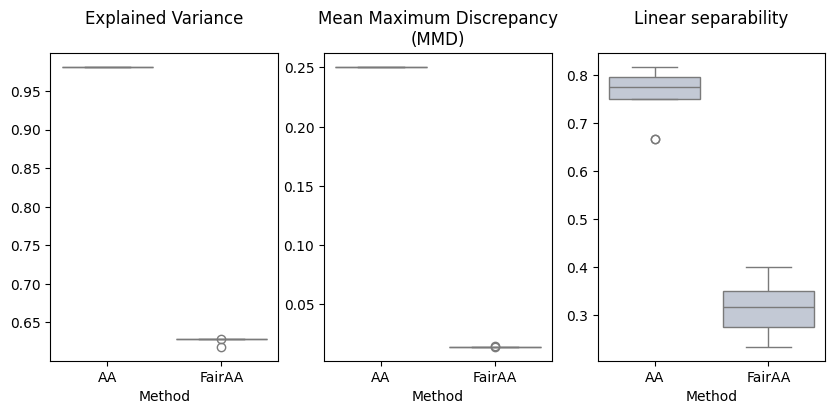

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# plot variance explained
sns.boxplot(data=metrics[metrics["metric"] == "explained_variance"], x="method", y="value", ax=ax[0])
ax[0].set_ylabel("")
ax[0]. set_xlabel("Method")
ax[0].set_title("Explained Variance\n")

# plot MMD
sns.boxplot(data=metrics[metrics["metric"] == "mmd"], x="method", y="value", ax=ax[1])
ax[1].set_ylabel("")
ax[1]. set_xlabel("Method")
ax[1].set_title("Mean Maximum Discrepancy\n(MMD)")

# plot linear separability
sns.boxplot(data=metrics[metrics["metric"] == "linear_separability"], x="method", y="value", ax=ax[2])
ax[2].set_ylabel("")
ax[2]. set_xlabel("Method")
ax[2].set_title("Linear separability\n")

if save_fig:
    plt.savefig("dummy_multi_metrics.pdf")

plt.show()

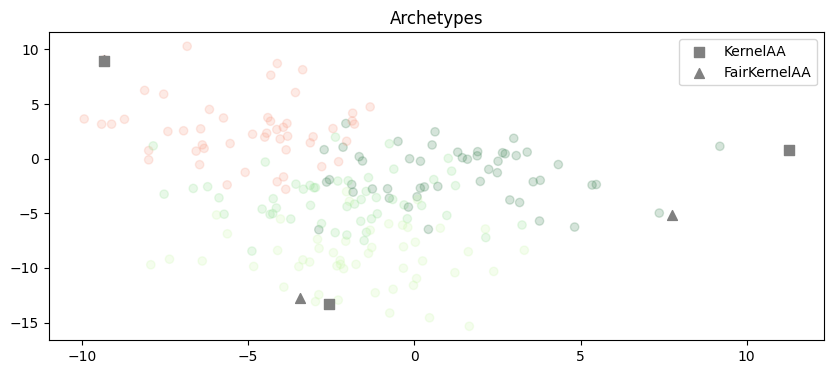

In [6]:
# plot archetypes

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.scatter(X[:, 0], X[:, 1], c=y, alpha=0.2)

ax.scatter(best_model.archetypes_[:, 0], best_model.archetypes_[:, 1], marker="s", s=50, color="gray", label="KernelAA")

ax.scatter(best_fair_model.archetypes_[:, 0], best_fair_model.archetypes_[:, 1], marker="^", s=50, color="gray", label="FairKernelAA")

ax.set_title("Archetypes")

ax.legend()

if save_fig:
    plt.savefig("dummy_multi_archetypes.pdf")

plt.show()

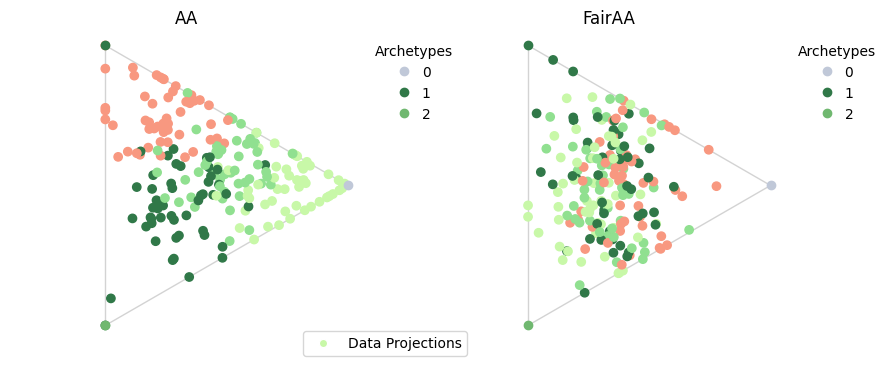

In [7]:
from archetypes.visualization import simplex


fig, ax = plt.subplots(1, 2, figsize=(10, 4))

simplex(
    best_model.similarity_degree_,
    ax=ax[0],
    c=y,
    color=None,
    show_vertices=True,
    )

# set title
ax[0].set_title("AA")

simplex(
    best_fair_model.similarity_degree_,
    ax=ax[1],
    c=y,
    color=None,
    show_vertices=True,
)

# set title
ax[1].set_title("FairAA")


# create custom legend for the figure

# Add a red point for archetypes, and a yellow point for data projections
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap.colors[0],
           markersize=mpl.rcParams['lines.markersize'], label='Data Projections'),
]

fig.legend(handles=legend_elements,  loc="center", bbox_to_anchor=(0.5, 0.1), ncol=2)


if save_fig:
    plt.savefig("dummy_multi_simplex.pdf")

plt.show()

